## (0) Loading Bibs and Data 

In [67]:
import pandas as pd
import matplotlib.pyplot as plt 
from ydata_profiling import ProfileReport
from collections import Counter
from langdetect import detect

%matplotlib inline

In [41]:
df = pd.read_excel('../../data/03_TweetEmotionsPTBR.xlsx')
df.drop(columns=['alegria',	'tristeza',	'raiva', 'medo', 'nojo', 'surpresa', 'confianca', 'antecipacao'], inplace=True)
print(df.shape)
df.head(3)

(12678, 2)


,texto,sentimento
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção
2,"A franquia continua ativa, com o desenvolvimen...",decepção


## (1) Data Overview an Descriptive Statistics

In [42]:
df.dtypes # data types

texto         object
sentimento    object
dtype: object

In [43]:
df[df.duplicated()] # check duplicated rows

,texto,sentimento
393,4. Um homem armado é um cidadão. Um homem desa...,submissão
401,5. atos relacionados como crimes (sejam de men...,agressividade
514,A felicidade da minha amiga irmã é a minha tô ...,alegria
830,"acho muito feio qualquer tipo de briga, eu ten...",medo
1008,agressivo,agressividade
...,...,...
12217,Um mau pressentimento,antecipacao
12218,Um mau pressentimento,antecipacao
12342,VALOR NACIONAL.\nInadmissível que o General HE...,nojo
12343,VALOR NACIONAL.\nInadmissível que o General HE...,nojo


In [44]:
df.isna().sum() # missing values per feature

texto         0
sentimento    0
dtype: int64

In [45]:
df.describe()

,texto,sentimento
count,12678,12678
unique,12420,16
top,mau pressentimento,tristeza
freq,14,812


In [46]:
df.sentimento.value_counts() # check the emotions balance

sentimento
tristeza         812
antecipacao      809
raiva            809
alegria          807
otimismo         806
confianca        805
desprezo         803
agressividade    802
decepção         801
nojo             799
amor             798
medo             798
submissão        797
remorso          785
surpresa         731
intimidação      716
Name: count, dtype: int64

In [ ]:
# Generate the report
profile = ProfileReport(df,title="TweetEmotionsPTBR Profile")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00,  5.48it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## (2) Statistical and structural analyses of the text

In [48]:
# Distribuição do tamanho dos textos
df['n_chars'] = df['texto'].str.len()
df['n_words'] = df['texto'].str.split().str.len()

print(df['n_chars'].describe())
print(80*"-")
print(df['n_words'].describe())

count    12678.000000
mean       114.917022
std         81.548031
min          4.000000
25%         48.000000
50%         90.000000
75%        171.000000
max        285.000000
Name: n_chars, dtype: float64
--------------------------------------------------------------------------------
count    12678.000000
mean        20.696167
std         14.581576
min          1.000000
25%          9.000000
50%         16.000000
75%         31.000000
max         62.000000
Name: n_words, dtype: float64


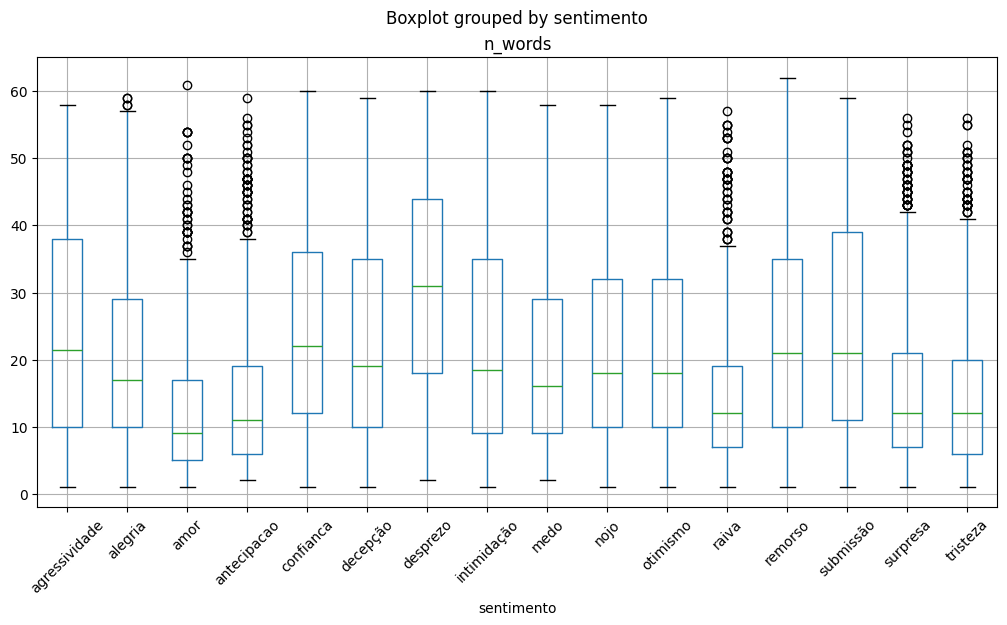

In [55]:
# Histogramas por sentimento
df.boxplot(column='n_words', by='sentimento', figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

In [59]:
# Número de textos vazios ou quase vazios
print((df['texto'].str.strip().str.len() == 0).sum())
print((df['texto'].str.strip().str.len() == 5).sum())

0
6


## (3) Balance and distribution analyses of the target

In [60]:
df.sentimento.value_counts(normalize=True)

sentimento
tristeza         0.064048
antecipacao      0.063811
raiva            0.063811
alegria          0.063654
otimismo         0.063575
confianca        0.063496
desprezo         0.063338
agressividade    0.063259
decepção         0.063180
nojo             0.063023
amor             0.062944
medo             0.062944
submissão        0.062865
remorso          0.061918
surpresa         0.057659
intimidação      0.056476
Name: proportion, dtype: float64

## (4) Word frequencies (without preprocessing)

In [62]:
Counter(" ".join(df['texto']).split()).most_common(30)

[('que', 7720),
 ('de', 7500),
 ('e', 6368),
 ('o', 5710),
 ('a', 5157),
 ('é', 3885),
 ('eu', 3621),
 ('com', 3423),
 ('não', 3275),
 ('um', 3051),
 ('do', 2800),
 ('da', 1992),
 ('se', 1800),
 ('uma', 1733),
 ('pra', 1706),
 ('em', 1677),
 ('no', 1611),
 ('q', 1602),
 ('mas', 1458),
 ('por', 1442),
 ('mais', 1401),
 ('me', 1397),
 ('na', 1282),
 ('tenho', 1127),
 ('ele', 1122),
 ('ser', 1115),
 ('tem', 979),
 ('os', 944),
 ('como', 930),
 ('só', 926)]

In [63]:
# por sentimento
Counter(" ".join(df[df.sentimento=='alegria']['texto']).split()).most_common(20)

[('e', 479),
 ('de', 423),
 ('que', 401),
 ('a', 380),
 ('o', 376),
 ('com', 279),
 ('eu', 216),
 ('é', 199),
 ('não', 185),
 ('contente', 175),
 ('do', 168),
 ('um', 147),
 ('em', 136),
 ('da', 129),
 ('estou', 118),
 ('pra', 115),
 ('se', 110),
 ('q', 104),
 ('no', 103),
 ('uma', 103)]

## (5) Detection of Emojis, Hashtags, and Mentions

In [64]:
df['has_emoji'] = df['texto'].str.contains(r'[\U00010000-\U0010ffff]')
df['has_hashtag'] = df['texto'].str.contains(r'#')
df['has_mention'] = df['texto'].str.contains(r'@')

df[['has_emoji','has_hashtag','has_mention']].mean()

has_emoji      0.000473
has_hashtag    0.026503
has_mention    0.017432
dtype: float64

## (6) Language checks

In [68]:
df['lang'] = df['texto'].apply(lambda x: detect(str(x)))
df.lang.value_counts().head()

lang
pt    11793
it      179
es      159
ca       99
fr       91
Name: count, dtype: int64

## (7) Duplicate text within the sentiment

In [69]:
df[df.duplicated(subset=['texto', 'sentimento'], keep=False)]

,texto,sentimento,n_chars,n_words,has_emoji,has_hashtag,has_mention,lang
11,Houthis: “O nosso país foi sujeito a um ataque...,agressividade,226,38,False,False,False,pt
13,q ódio,raiva,6,2,False,False,False,es
392,4. Um homem armado é um cidadão. Um homem desa...,submissão,212,36,False,False,False,pt
393,4. Um homem armado é um cidadão. Um homem desa...,submissão,212,36,False,False,False,pt
400,5. atos relacionados como crimes (sejam de men...,agressividade,273,43,False,False,False,pt
...,...,...,...,...,...,...,...,...
12341,VALOR NACIONAL.\nInadmissível que o General HE...,nojo,250,35,False,False,False,pt
12342,VALOR NACIONAL.\nInadmissível que o General HE...,nojo,250,35,False,False,False,pt
12343,VALOR NACIONAL.\nInadmissível que o General HE...,nojo,250,35,False,False,False,pt
12507,Vim no mercado peguei umas 7 coisas e tenho CE...,confianca,70,14,False,False,False,pt


## (8) Texts that appear with different sentiments (label inconsistency)

In [70]:
df.groupby('texto')['sentimento'].nunique().sort_values(ascending=False).head()

conflicts = df.groupby('texto').sentimento.unique().reset_index()
conflicts[conflicts.sentimento.apply(len) > 1]

,texto,sentimento


## (9) Correlation between text length and sentiment

In [71]:
df.groupby('sentimento')['n_words'].mean()

sentimento
agressividade    24.189526
alegria          20.744734
amor             12.785714
antecipacao      14.650185
confianca        24.885714
decepção         22.993758
desprezo         30.698630
intimidação      22.220670
medo             20.378446
nojo             21.929912
otimismo         21.509926
raiva            14.844252
remorso          23.565605
submissão        24.392723
surpresa         16.073871
tristeza         15.219212
Name: n_words, dtype: float64

## (10) Ponctuation Frequency

In [72]:
df['n_exclamacoes'] = df['texto'].str.count('!')
df['n_interrog'] = df['texto'].str.count('\?')

df.groupby('sentimento')[['n_exclamacoes','n_interrog']].mean()

<>:2: SyntaxWarning: invalid escape sequence '\?'
<>:2: SyntaxWarning: invalid escape sequence '\?'
C:\Users\luan.barbosa\AppData\Local\Temp\ipykernel_3636\920072170.py:2: SyntaxWarning: invalid escape sequence '\?'
  df['n_interrog'] = df['texto'].str.count('\?')


,n_exclamacoes,n_interrog
sentimento,,
agressividade,0.114713,0.152120
alegria,0.226766,0.135068
amor,0.180451,0.101504
antecipacao,0.085290,0.093943
confianca,0.242236,0.098137
decepção,0.258427,0.107366
desprezo,0.196762,0.180573
intimidação,0.155028,0.236034
medo,0.144110,0.185464
